Robust MPC: Simulation with linearized rocket system

In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
from LandMPC.MPCControl_z import MPCControl_z
from src.rocket import Rocket
from src.pos_rocket_vis import *

# Require ipympl
%matplotlib widget 

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

sim_time = 10.0  # simulation length in seconds
x0 = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10])
x_ref = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3])
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)
sys = rocket.linearize_sys(xs, us)
A, B = sys.A, sys.B

H = 10.0
mpc = MPCControl_z(A, B, xs, us, Ts, H)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Linearization around a steady state:
x_ref =  [0 0 0 0 0 0 0 0 0 0 0 3]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


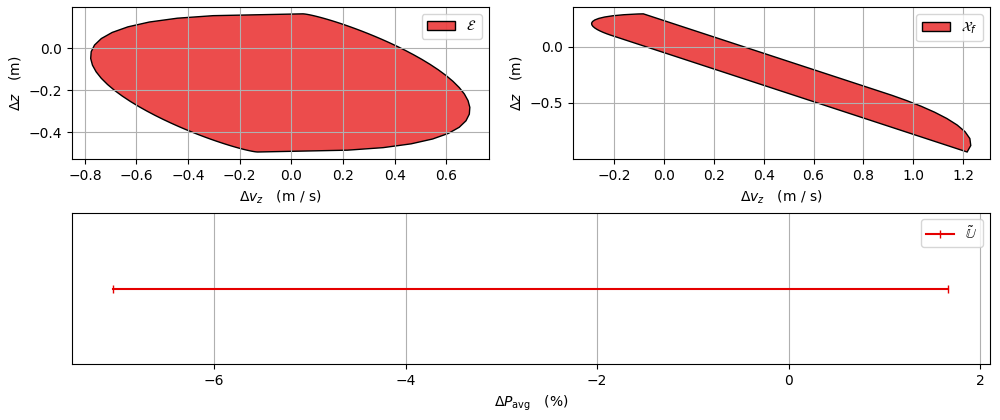

In [3]:
assert not mpc.E.is_empty
assert not mpc.X_tilde.is_empty
assert not mpc.U_tilde.is_empty
assert not mpc.Xf_tilde.is_empty

OPACITY = 0.7
COLOR = 'xkcd:red'

plt.close('all')
plt.figure('Terminal invariant set', (10, 4.2))

ax = plt.subplot(221)
mpc.E.plot(ax, color=COLOR, opacity=OPACITY, show_edges=True, show_vertices=False, label=r'$\mathcal{E}$')
ax.set_xlabel(r'$\Delta v_z \quad (\text{m / s})$')
ax.set_ylabel(r'$\Delta z \quad (\text{m})$')
ax.legend()
ax.grid()

ax = plt.subplot(222)
mpc.Xf_tilde.plot(ax, color=COLOR, opacity=OPACITY, show_edges=True, show_vertices=False, label=r'$\mathcal{X}_f$')
ax.set_xlabel(r'$\Delta v_z \quad (\text{m / s})$')
ax.set_ylabel(r'$\Delta z \quad (\text{m})$')
ax.legend()
ax.grid()

ax = plt.subplot(212)
ax.plot(mpc.U_tilde.V[:, 0], np.zeros_like(mpc.U_tilde.V)[:, 0], color=COLOR, marker='|', label=r'$\tilde{\mathbb{U}}$')
ax.set_xlabel(r'$\Delta P_\text{avg} \quad (\%)$')
ax.set_yticks([])
ax.legend()
ax.grid()

plt.tight_layout(pad=0.5)
plt.show()
plt.savefig('tightened-sets')

In [4]:
t_cl, x_cl, u_cl = rocket.simulate_subsystem(mpc, sim_time, x0, w_type='random')

c:\Users\killi\Desktop\MPC-Course-EPFL\.env\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


In [5]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000022F0CDB3EC0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000022F0CDB3EC0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most rec

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\phi\\theta\\psi}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: >,
  <Axes: ylabel='$\\phi\\theta\\psi$ (deg)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: ylabel='$v_{\\text{ENU}}$ (m/s)'>,
  <Axes: >,
  <Axes: >,
  <Axes: ylabel='$\\text{pos}_{\\text{ENU}}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x22f6dfcf8c0>,
 'scene_objects': {'rocket_actor': Actor (0x22fb2a2c4c0)
    Center:                     (0.32006999999999997, -0.0015085000000000237, 10.5884845)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -6.402E-01, 1.280E+00
    Y Bounds           

 JS Error => error: Uncaught SyntaxError: Unexpected number
 JS Error => error: Uncaught SyntaxError: Unexpected string
 JS Error => error: Uncaught SyntaxError: Unexpected string
 JS Error => error: Uncaught SyntaxError: Unexpected number


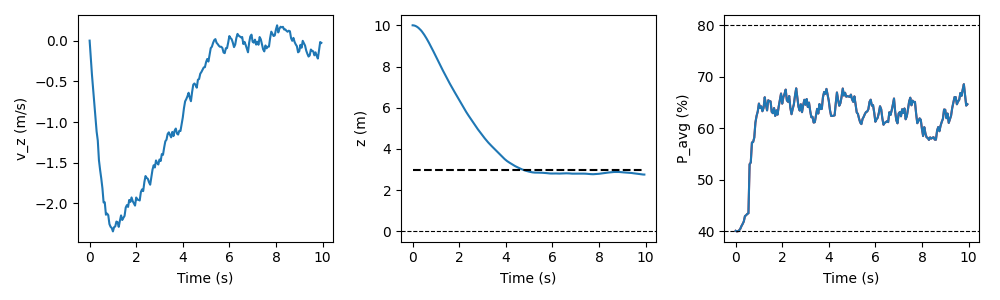

In [6]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs, 'sys_z')
plt.savefig('sys-z-random-noise')

In [7]:
t_cl, x_cl, u_cl = rocket.simulate_subsystem(mpc, sim_time, x0, w_type='extreme')

In [8]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\phi\\theta\\psi}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: >,
  <Axes: ylabel='$\\phi\\theta\\psi$ (deg)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: ylabel='$v_{\\text{ENU}}$ (m/s)'>,
  <Axes: >,
  <Axes: >,
  <Axes: ylabel='$\\text{pos}_{\\text{ENU}}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x22fbc63e710>,
 'scene_objects': {'rocket_actor': Actor (0x22fbc5b8460)
    Center:                     (0.32006999999999997, -0.0015085000000000237, 10.5884845)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -6.402E-01, 1.280E+00
    Y Bounds           

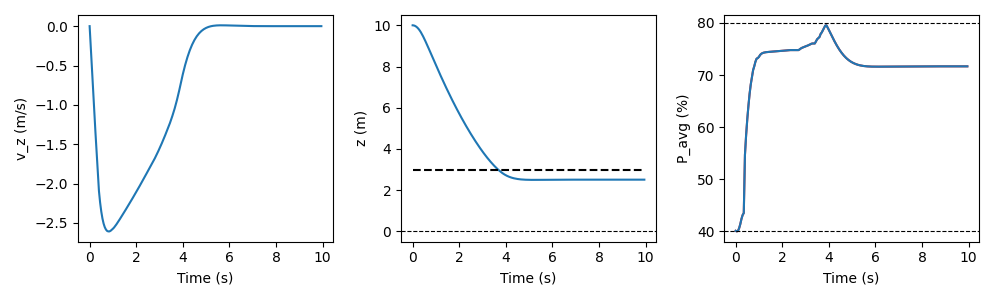

In [9]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs, 'sys_z')
plt.savefig('sys-z-extreme-noise')